In [ ]:
#setup
#%pip install requests
#%pip install openmeteo-requests
#%pip install requests-cache retry-requests numpy pandas
#%pip install matplotlib
#%pip install scipy
import requests
import json
import openmeteo_requests
import requests_cache
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import time
from retry_requests import retry

In [ ]:
# get matches and teams
matches = {}
teams = {}

# do the analysis for all the leagues (takes over 10 minutes!)
response = json.loads(requests.get("https://api.openligadb.de/getavailableleagues").text)
response = list(filter(lambda x: "1. Fußball-Bundesliga" in x["leagueName"] and "26" not in x, response)) # completed Bundesliga seasons only
for league in response:
    try:
        matches[league["leagueName"]] = json.loads(requests.get(f"https://api.openligadb.de/getmatchdata/{league['leagueShortcut']}/{league['leagueSeason']}").text)
        teams[league["leagueName"]] = json.loads(requests.get(f"https://api.openligadb.de/getavailableteams/{league['leagueShortcut']}/{league['leagueSeason']}").text)
    except: 
        pass

# comment the above and uncomment this to analyze only the 22/23 season
#matches["1. Fussball-Bundesliga 2022/2023"] = json.loads(requests.get("https://api.openligadb.de/getmatchdata/bl1/2022").text)
#teams["1. Fussball-Bundesliga 2022/2023"] = json.loads(requests.get("https://api.openligadb.de/getavailableteams/bl1/2022").text)

In [ ]:
# get weather on the day of each match
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

location_map = {}
for match_collection in matches.values():
    for match in match_collection:
        if not match["matchDateTime"] or not match["location"] or not match["location"]["locationCity"]: 
            # if the location of the match isn't recorded, use the short name of the home team (which is usually their city)
            if match["team1"]["shortName"]:
                match["location"] = {"locationCity":match["team1"]["shortName"].strip()}
            else:
                continue # skip entries with missing data
        location = match["location"]["locationCity"]
        if location not in location_map:
            coords = json.loads(requests.get(f"https://geocoding-api.open-meteo.com/v1/search?name={location}&language=de&countryCode=DE&count=3").text)
            if "results" not in coords: 
                print(f"Found no result when searching '{location}'")
                location_map[location] = None
                continue
            # the api often finds multiple results, but the first one always seems to be correct
            location_map[location]=(coords["results"][0]["latitude"], coords["results"][0]["longitude"])

# remove matches with missing data
for match_collection in matches:
    matches[match_collection] = list(filter(lambda match: match["matchDateTime"] and match["location"] and match["location"]["locationCity"] and location_map[match["location"]["locationCity"]] and match["matchResults"], matches[match_collection]))

j=0
flattened_matches=[]
for match_collection in matches.values():
    for match in match_collection:
        match_date = match["matchDateTime"][:10] # first 10 chars are date, rest is time
        params={
            "latitude": location_map[match["location"]["locationCity"]][0],
            "longitude" :location_map[match["location"]["locationCity"]][1],
            "start_date": match_date,
            "end_date": match_date,
            "daily": ["precipitation_sum", "rain_sum"],
        }
        # dis shit ugly as hell
        weather = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0].Daily()
        time.sleep(0.08) # make sure to stay below rate limit
        match["precipitation"]=weather.Variables(0).ValuesAsNumpy()[0]
        match["rain"]=weather.Variables(1).ValuesAsNumpy()[0] # units are mm
        flattened_matches.append(match)
        print(j,end=" ")
        j+=1



In [5]:
# bring team data into a better format (Question 2)
team_dict = {}
for league in teams:
    for team in teams[league]:
        team["matches"] = []
        if team["teamName"] not in team_dict:
            team_dict[team["teamName"]] = team


In [ ]:
# give each team a list of matches including result and weather (Question 2)
for match in flattened_matches:
    team_dict[match["team1"]["teamName"]]["matches"].append([match["matchResults"][0]["pointsTeam1"], match["rain"], match["precipitation"]])
    team_dict[match["team2"]["teamName"]]["matches"].append([match["matchResults"][0]["pointsTeam2"], match["rain"], match["precipitation"]])

# remove teams with little or no data
team_dict=dict(filter(lambda team: len(team[1]["matches"])>30, team_dict.items()))

Text(0.5, 1.0, 'Goals distribution for teams from some Bundesliga\nseasons across games with less than 1.5mm of rainfall')

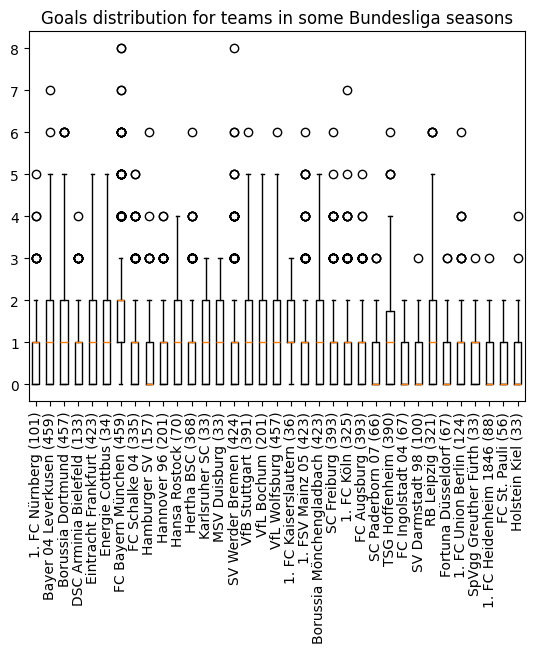

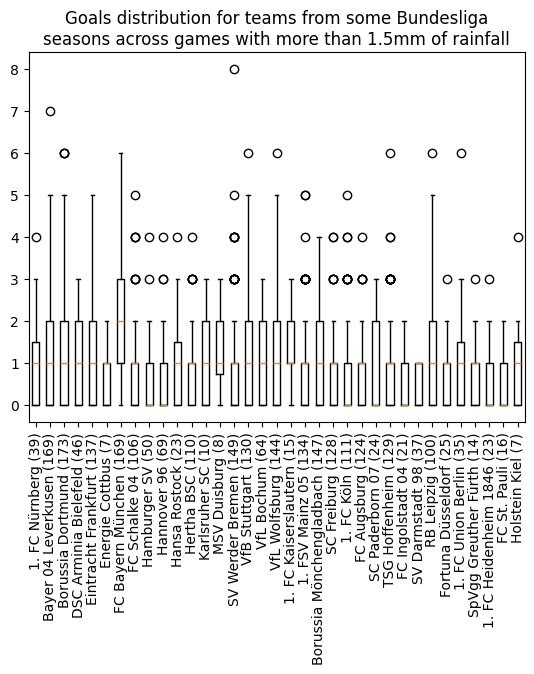

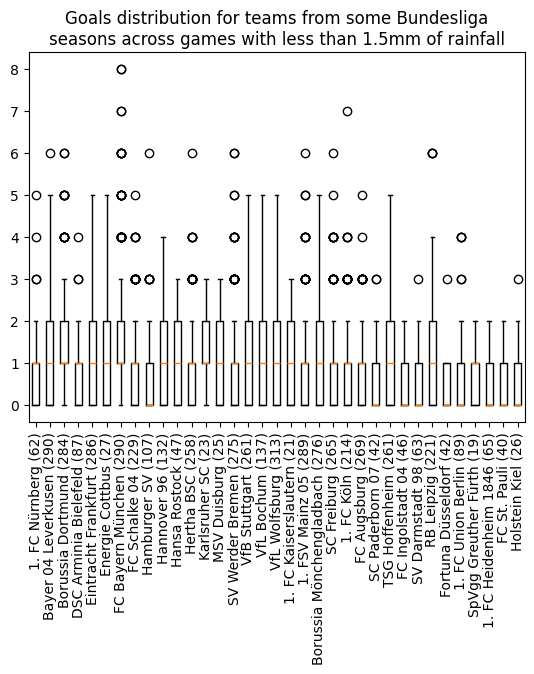

In [7]:
# graphical representation (Question 2)
fig, ax = plt.subplots()
ax.boxplot([np.array(team["matches"]).transpose()[0] for team in team_dict.values()])
ax.set_xticklabels([team + " (" + str(len(team_dict[team]["matches"])) + ")" for team in team_dict.keys()],rotation=90)
ax.set_title("Goals distribution for teams in some Bundesliga seasons")

fig2, ax2 = plt.subplots()
ax2.boxplot([np.array([match for match in team["matches"] if match[2] > 1.5]).transpose()[0] for team in team_dict.values()])
ax2.set_xticklabels([team + " (" + str(len([match for match in team_dict[team]["matches"] if match[2] > 1.5])) + ")" for team in team_dict.keys()],rotation=90)
ax2.set_title("Goals distribution for teams from some Bundesliga\nseasons across games with more than 1.5mm of rainfall")

fig3, ax3 = plt.subplots()
ax3.boxplot([np.array([match for match in team["matches"] if match[2] <= 1.5]).transpose()[0] for team in team_dict.values()])
ax3.set_xticklabels([team + " (" + str(len([match for match in team_dict[team]["matches"] if match[2] <= 1.5])) + ")" for team in team_dict.keys()],rotation=90)
ax3.set_title("Goals distribution for teams from some Bundesliga\nseasons across games with less than 1.5mm of rainfall")

Text(0.5, 0, '# Matches')

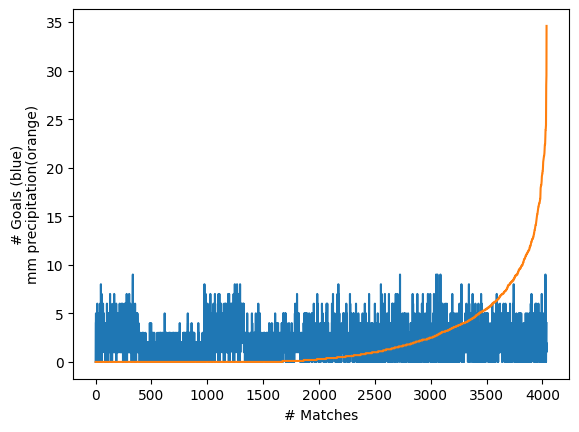

In [ ]:
# graphical representation (Question 3)
# extract relevant data and sort
data = np.array(sorted([(match["matchResults"][0]["pointsTeam1"] + match["matchResults"][0]["pointsTeam2"], match["rain"], match["precipitation"]) for match in flattened_matches], key = lambda match: match[2])).transpose()
plot = plt.plot(range(len(data[0])), data[0]) # plot number of goals
#plot.append(plt.plot(range(len(data[0])), data[1])) # plot rain
plot.append(plt.plot(range(len(data[0])), data[2])) # plot precipitation
plt.ylabel("# Goals (blue)\nmm precipitation(orange)")
plt.xlabel("# Matches")